# Adjacency Graph - Israel Cantons Project

This notebook builds the spatial adjacency graph from municipality polygons.
All core logic lives in `src/graph/adjacency.py`.

Steps:
1. Load GeoJSON and dissolve multi-polygons
2. Build adjacency graph (shared boundaries)
3. Inspect connectivity and neighbours
4. Save graph data

In [1]:
import sys
sys.path.insert(0, '..')

import json
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

from src.config import DATA_RAW, DATA_PROCESSED
from src.data.loader import load_municipality_geojson
from src.graph.adjacency import dissolve_municipalities, build_adjacency_graph, get_graph_stats

DATA_PROCESSED.mkdir(exist_ok=True)
print("Setup complete")

Setup complete


## 1. Load and Dissolve GeoJSON

In [2]:
geo = load_municipality_geojson()
print(f"Loaded {len(geo)} polygons, {geo['MUN_HEB'].nunique()} unique municipalities")

geo_dissolved = dissolve_municipalities(geo)
print(f"After dissolve: {len(geo_dissolved)} municipalities")

Loaded 429 polygons, 235 unique municipalities
After dissolve: 234 municipalities


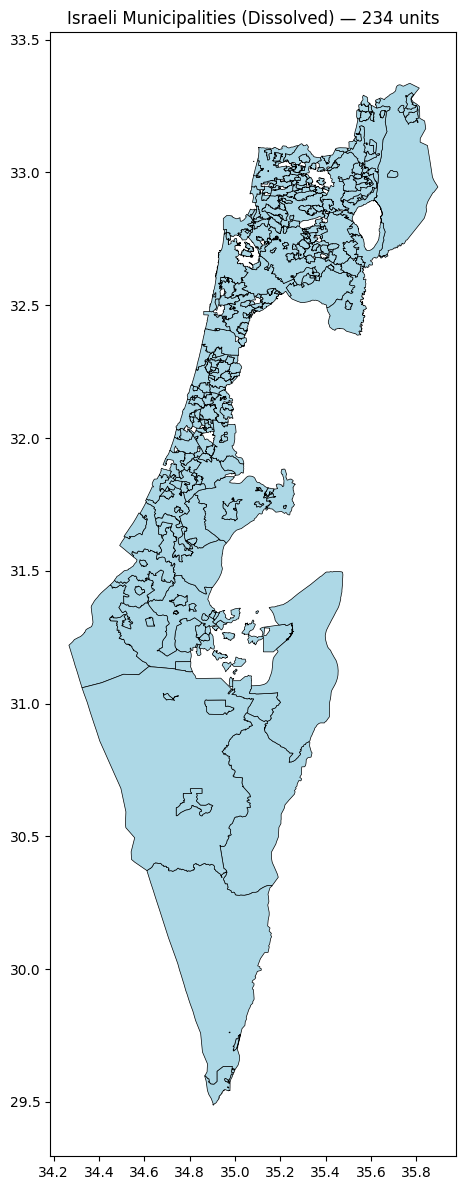

In [3]:
# Visualize dissolved map
fig, ax = plt.subplots(figsize=(10, 12))
geo_dissolved.plot(ax=ax, edgecolor='black', linewidth=0.5, facecolor='lightblue')
ax.set_title(f'Israeli Municipalities (Dissolved) — {len(geo_dissolved)} units')
plt.tight_layout()
plt.show()

## 2. Build Adjacency Graph

In [4]:
print("Building adjacency graph (this may take a moment)...")
G = build_adjacency_graph(geo_dissolved)

stats = get_graph_stats(G)
print("\nGraph Statistics:")
for k, v in stats.items():
    print(f"  {k}: {v}")

Building adjacency graph (this may take a moment)...



Graph Statistics:
  nodes: 234
  edges: 516
  avg_degree: 4.410256410256411
  min_degree: 0
  max_degree: 27
  n_components: 5
  largest_component: 229
  isolated_nodes: 3


## 3. Connectivity Analysis

In [5]:
components = list(nx.connected_components(G))
print(f"Connected components: {len(components)}")

if len(components) > 1:
    for i, comp in enumerate(sorted(components, key=len, reverse=True)):
        print(f"  Component {i+1}: {len(comp)} nodes")
        if len(comp) < 10:
            print(f"    Nodes: {comp}")
else:
    print("Graph is fully connected!")

Connected components: 5
  Component 1: 229 nodes
  Component 2: 2 nodes
    Nodes: {'עוספייא', 'דאלית אל-כרמל'}
  Component 3: 1 nodes
    Nodes: {"בית ג'ן"}
  Component 4: 1 nodes
    Nodes: {'כסייפה'}
  Component 5: 1 nodes
    Nodes: {'ערערה בנגב'}


In [6]:
# Neighbours of major cities
cities = ['תל אביב - יפו', 'ירושלים', 'חיפה', 'באר שבע', 'אשדוד']

print("Neighbours of major cities:")
for city in cities:
    if city in G:
        nbrs = list(G.neighbors(city))
        print(f"\n{city} ({len(nbrs)} neighbours): {', '.join(nbrs)}")
    else:
        print(f"\n{city}: NOT IN GRAPH")

Neighbours of major cities:

תל אביב - יפו: NOT IN GRAPH

ירושלים (2 neighbours): מבשרת ציון, מטה יהודה

חיפה (7 neighbours): זבולון, טירת כרמל, נשר, קרית אתא, קרית ביאליק, קרית ים, קרית מוצקין

באר שבע (5 neighbours): בני שמעון, מרחבים, עומר, שגב שלום, תל שבע

אשדוד (3 neighbours): באר טוביה, גן יבנה, חבל יבנה


In [7]:
# Top/bottom municipalities by degree
degree_dict = dict(G.degree())
sorted_by_degree = sorted(degree_dict.items(), key=lambda x: -x[1])

print("Top 10 by neighbours:")
for m, d in sorted_by_degree[:10]:
    print(f"  {m}: {d}")

print("\nBottom 10 (potential islands):")
for m, d in sorted_by_degree[-10:]:
    print(f"  {m}: {d}")

Top 10 by neighbours:
  עמק יזרעאל: 27
  משגב: 26
  דרום השרון: 21
  מטה אשר: 21
  הגליל התחתון: 16
  מעלה יוסף: 15
  מנשה: 14
  בני שמעון: 13
  הגליל העליון: 13
  מרום הגליל: 13

Bottom 10 (potential islands):
  קרית מלאכי: 1
  רהט: 1
  רכסים: 1
  רמת ישי: 1
  שדרות: 1
  שהם: 1
  שלומי: 1
  בית ג'ן: 0
  כסייפה: 0
  ערערה בנגב: 0


## 4. Visualize Connectivity

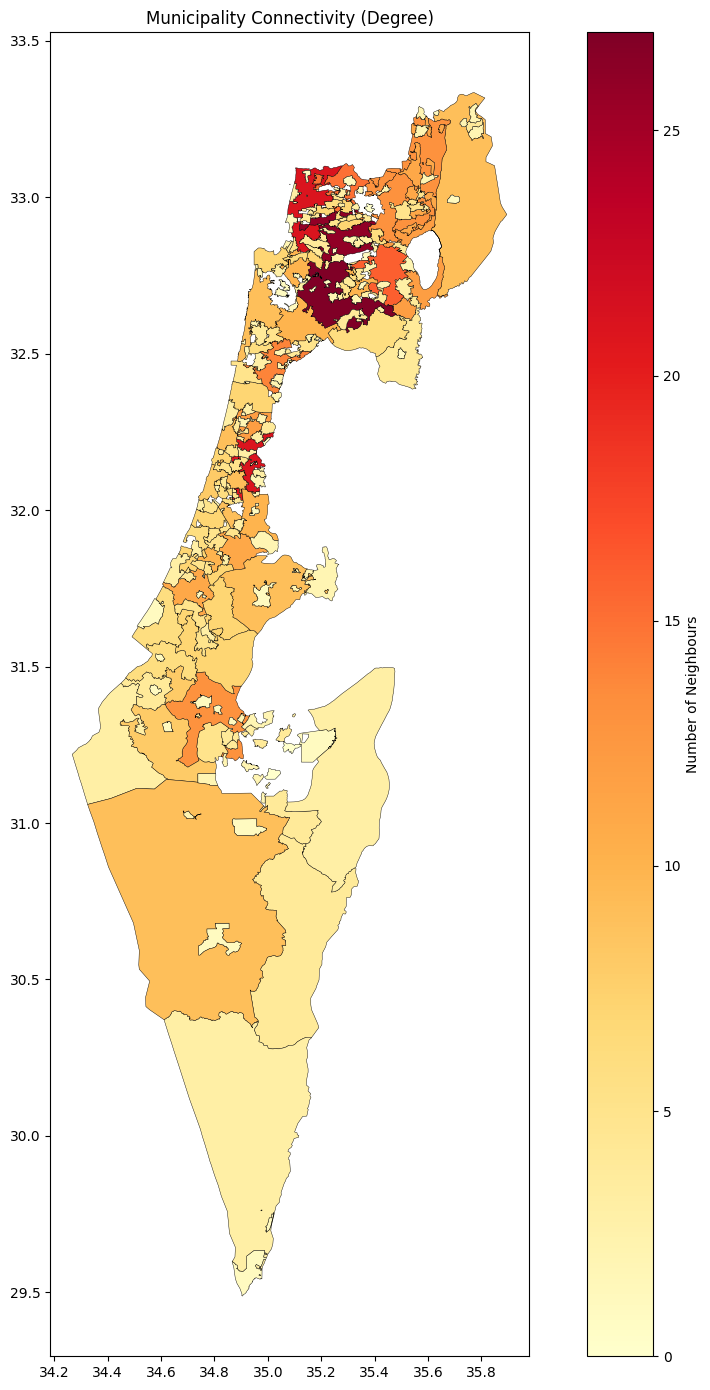

In [8]:
geo_dissolved['degree'] = geo_dissolved['MUN_HEB'].map(degree_dict)

fig, ax = plt.subplots(figsize=(12, 14))
geo_dissolved.plot(column='degree', ax=ax, legend=True,
                   cmap='YlOrRd', edgecolor='black', linewidth=0.3,
                   legend_kwds={'label': 'Number of Neighbours'})
ax.set_title('Municipality Connectivity (Degree)')
plt.tight_layout()
plt.show()

## 5. Save Graph Data

In [9]:
# Adjacency list JSON
adj_list = {node: list(G.neighbors(node)) for node in G.nodes()}
with open(DATA_PROCESSED / 'adjacency_graph.json', 'w', encoding='utf-8') as f:
    json.dump(adj_list, f, ensure_ascii=False, indent=2)
print(f"Saved adjacency_graph.json ({len(adj_list)} municipalities)")

# Edge list CSV
edges_df = pd.DataFrame(G.edges(), columns=['municipality_1', 'municipality_2'])
edges_df.to_csv(DATA_PROCESSED / 'adjacency_edges.csv', index=False, encoding='utf-8')
print(f"Saved adjacency_edges.csv ({len(edges_df)} edges)")

# Dissolved GeoJSON
geo_dissolved.to_file(DATA_PROCESSED / 'municipalities_dissolved.geojson', driver='GeoJSON')
print(f"Saved municipalities_dissolved.geojson ({len(geo_dissolved)} municipalities)")

Saved adjacency_graph.json (234 municipalities)
Saved adjacency_edges.csv (516 edges)


Saved municipalities_dissolved.geojson (234 municipalities)
